<a href="https://colab.research.google.com/github/2403a52009-bot/NLP/blob/main/ml_Asn_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 9: K-Nearest Neighbors (KNN) - Classification  

Dataset: Heart Disease UCI  

---
## Objective
Implement KNN classifier for different values of k.
Analyze effect of k on performance and overfitting/underfitting.


## STEP 1 — Import Required Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


## STEP 2 — Load Dataset

In [6]:

df = pd.read_csv("/heart_disease_uci.csv")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



## STEP 3 — Preprocessing

- Handle missing values
- Encode categorical columns if required


In [7]:

# Drop rows with missing values
df = df.dropna()

# One-hot encode categorical columns if present
df = pd.get_dummies(df, drop_first=True)

print("After preprocessing shape:", df.shape)


After preprocessing shape: (299, 22)



## STEP 4 — Feature Selection

Target column assumed as 'target'.


In [9]:
target_column = 'num'

# Binarize the target column: 0 for no disease, 1 for disease (num > 0)
df['target_binary'] = (df[target_column] > 0).astype(int)

X = df.drop(columns=[target_column, 'target_binary'])
y = df['target_binary']

## STEP 5 — Train-Test Split (80/20)

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## STEP 6 — Apply StandardScaler

In [11]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## STEP 7 — Train KNN for Different k Values

In [12]:

k_values = [3, 5, 7, 11, 15]

accuracy_scores = []
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracy_scores.append(acc)
    f1_scores.append(f1)

    print(f"Results for k = {k}")
    print("Accuracy:", acc)
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1)
    print("-"*40)


Results for k = 3
Accuracy: 0.8166666666666667
Precision: 0.8695652173913043
Recall: 0.7142857142857143
F1-score: 0.7843137254901961
----------------------------------------
Results for k = 5
Accuracy: 0.8333333333333334
Precision: 0.9090909090909091
Recall: 0.7142857142857143
F1-score: 0.8
----------------------------------------
Results for k = 7
Accuracy: 0.8333333333333334
Precision: 0.9090909090909091
Recall: 0.7142857142857143
F1-score: 0.8
----------------------------------------
Results for k = 11
Accuracy: 0.8333333333333334
Precision: 0.875
Recall: 0.75
F1-score: 0.8076923076923077
----------------------------------------
Results for k = 15
Accuracy: 0.85
Precision: 0.88
Recall: 0.7857142857142857
F1-score: 0.8301886792452831
----------------------------------------


## STEP 8 — Plot k vs F1-score

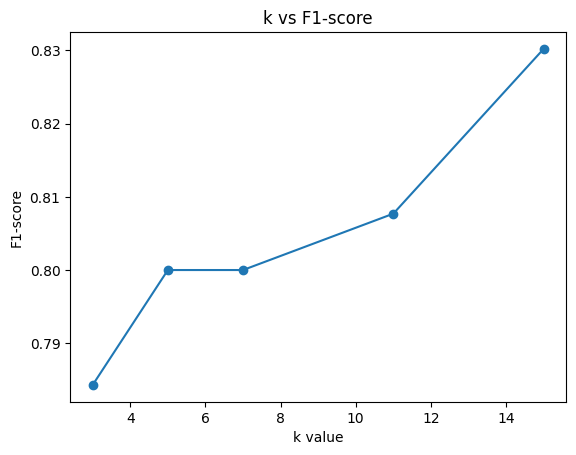

In [13]:

plt.figure()
plt.plot(k_values, f1_scores, marker='o')
plt.xlabel("k value")
plt.ylabel("F1-score")
plt.title("k vs F1-score")
plt.show()



## Conclusion

Small k values (e.g., k=3) may cause overfitting.
Large k values may cause underfitting.
Optimal k balances bias and variance.
Best k is selected based on highest F1-score.
